In [46]:
import os
import sys
sys.path.append(os.path.abspath("vanguard/notebooks"))
from skeleton3d_utils.skeleton3d import skeletonize3d, _OFFSETS_3D
from skeleton3d_utils.skeleton3d_visuals import edges_to_segments, plot_skeleton3d, plot_skeleton_projections
 
import numpy as np
import json

### Step 1. Import image. 
The image we will be using as input comes from Step 3 of the Prediction Workflow ipynb. The `final_image` has three channels (first dimension), which are probabilities that a given pixel is fibroglandular tissue, blood vessel, or neither. Each channel is represented as a three-dimensional array with probabilities. 

In [36]:
final_image = np.load("vanguard/notebooks/skeleton3d_usage/sample.npy")
print(f"Probabilities should be between 0 and 1")
print(np.min(final_image), np.max(final_image))
print(f"The sum of the three channels must be close to 1")
print(np.isclose(np.sum(final_image, axis=0), 1, rtol=0.002).all())

Probabilities should be between 0 and 1
0.0 1.0
The sum of the three channels must be close to 1
True


### Step 2. Keep blood vessels
We will only use channel 1 of each image. Channel 1 represents probabilities of each voxel being part of a blood vessel.

In [37]:
vessels = final_image[1]

In [38]:
print("Shape:", vessels.shape)
print("Data type:", vessels.dtype)
print("Min:", np.min(vessels))
print("Max:", np.max(vessels))
print("Unique values (sample):", np.unique(vessels)[:10])

Shape: (448, 448, 160)
Data type: float16
Min: 0.0
Max: 1.0
Unique values (sample): [0.0e+00 6.0e-08 1.2e-07 1.8e-07 2.4e-07 3.0e-07 3.6e-07 4.2e-07 4.8e-07
 5.4e-07]


### Step 3. Skeletonize 3D image
The next step consists on skeletonize a 3D image using skeletonize3d() and a predefined probability threshold.

In [39]:
skeleton = skeletonize3d(vessels, threshold=0.999)

In [40]:
print("Shape:", skeleton.shape)
print("Data type:", skeleton.dtype)
print("Min:", np.min(skeleton))
print("Max:", np.max(skeleton))
print("Unique values (sample):", np.unique(skeleton)[:10])

Shape: (448, 448, 160)
Data type: uint32
Min: 0
Max: 41943056
Unique values (sample): [ 0  1  2  4  8 12 16 32 64 66]


In [48]:
def skeleton_to_json(edges: np.ndarray, filename: str) -> None:
    """Convert a 3D uint32 skeleton array into a JSON graph."""
    assert edges.ndim == 3 and edges.dtype == np.uint32

    # 1️⃣ Extract nonzero voxels (skeleton nodes)
    coords = np.argwhere(edges > 0)
    node_ids = {tuple(coord): i for i, coord in enumerate(coords)}
    nodes = [{"id": int(i), "z": int(z), "y": int(y), "x": int(x)}
             for i, (z, y, x) in enumerate(coords)]

    # 2️⃣ Build edges (avoid duplicates)
    edges_list = []
    for i, (z, y, x) in enumerate(coords):
        mask = int(edges[z, y, x])
        for b in range(26):
            if (mask >> b) & 1:
                dz, dy, dx = _OFFSETS_3D[b]
                nz, ny, nx = z + dz, y + dy, x + dx
                neighbor = (nz, ny, nx)
                # only add if neighbor exists and to avoid double-count
                if neighbor in node_ids and node_ids[neighbor] > i:
                    edges_list.append({
                        "source": i,
                        "target": node_ids[neighbor]
                    })

    graph = {
        "nodes": nodes,
        "edges": edges_list,
        "metadata": {"shape": edges.shape, "dtype": str(edges.dtype)}
    }

    return graph
    print(f"Exported {len(nodes)} nodes and {len(edges_list)} edges to {filename}")

In [49]:
skeleton_to_json(skeleton, "graph_to_json_try")

{'nodes': [{'id': 0, 'z': 114, 'y': 344, 'x': 88},
  {'id': 1, 'z': 114, 'y': 345, 'x': 88},
  {'id': 2, 'z': 114, 'y': 346, 'x': 89},
  {'id': 3, 'z': 114, 'y': 347, 'x': 89},
  {'id': 4, 'z': 115, 'y': 341, 'x': 88},
  {'id': 5, 'z': 115, 'y': 342, 'x': 88},
  {'id': 6, 'z': 115, 'y': 343, 'x': 88},
  {'id': 7, 'z': 116, 'y': 340, 'x': 89},
  {'id': 8, 'z': 117, 'y': 339, 'x': 89},
  {'id': 9, 'z': 118, 'y': 335, 'x': 91},
  {'id': 10, 'z': 118, 'y': 336, 'x': 90},
  {'id': 11, 'z': 118, 'y': 337, 'x': 90},
  {'id': 12, 'z': 118, 'y': 338, 'x': 90},
  {'id': 13, 'z': 119, 'y': 172, 'x': 65},
  {'id': 14, 'z': 119, 'y': 334, 'x': 92},
  {'id': 15, 'z': 120, 'y': 173, 'x': 66},
  {'id': 16, 'z': 120, 'y': 334, 'x': 93},
  {'id': 17, 'z': 121, 'y': 173, 'x': 66},
  {'id': 18, 'z': 121, 'y': 333, 'x': 94},
  {'id': 19, 'z': 122, 'y': 174, 'x': 66},
  {'id': 20, 'z': 122, 'y': 333, 'x': 95},
  {'id': 21, 'z': 123, 'y': 175, 'x': 67},
  {'id': 22, 'z': 123, 'y': 332, 'x': 96},
  {'id': 23,

### Step 4. Visualize the output

In [41]:
segments = edges_to_segments(skeleton)
print(f"{len(segments)} line segments extracted")

1897 line segments extracted


In [42]:
fig = plot_skeleton3d(segments)
fig.show()

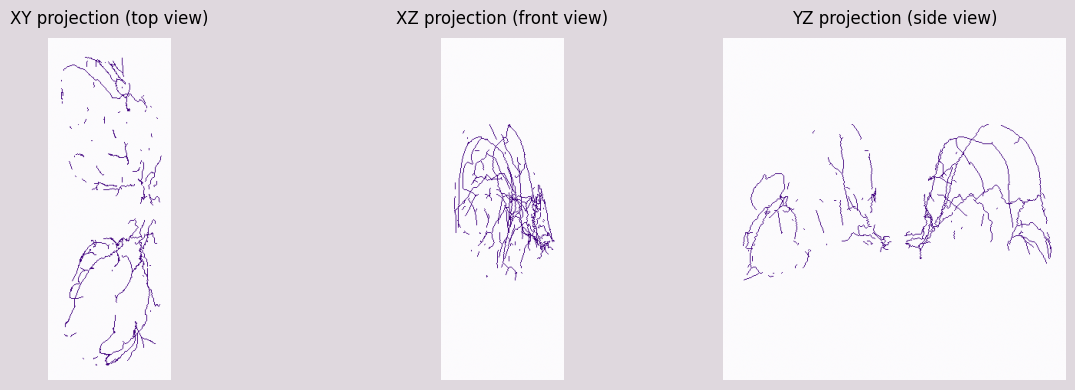

In [26]:
plot_skeleton_projections(skeleton)